Posterior Mean           :  0.4090909 
Posterior Variance       :  0.0105102 
Posterior Std. Deviation :  0.1025195 

Prob.	Quantile 
------	---------
0.005	0.1706707
0.010	0.1891227
0.025	0.2181969
0.050	0.2449944
0.500	0.4062879
0.950	0.5828013
0.975	0.6156456
0.990	0.6527600
0.995	0.6772251


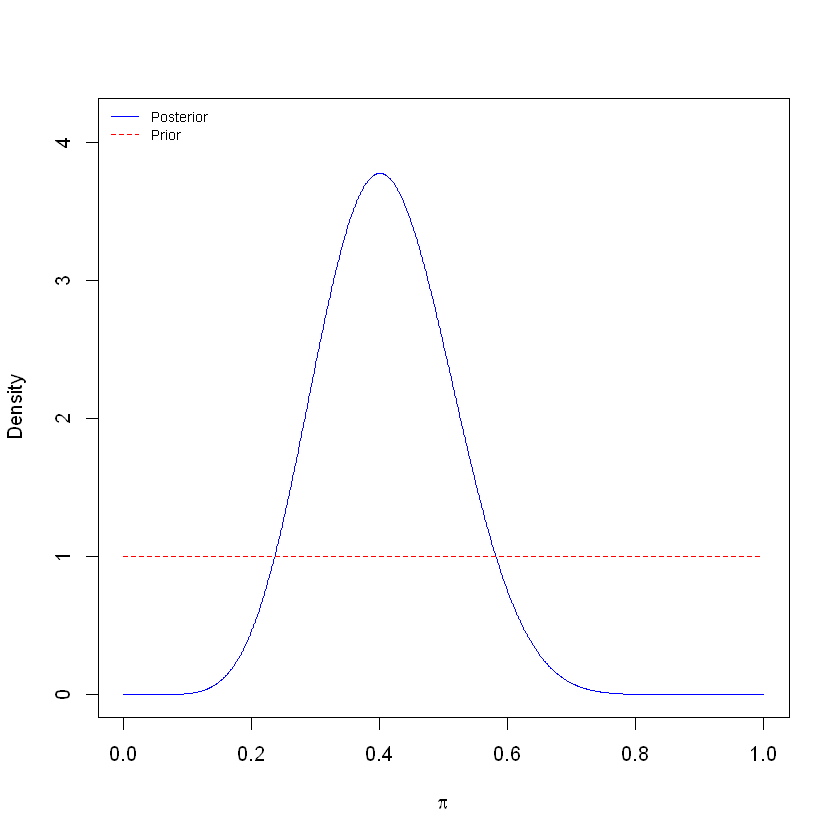

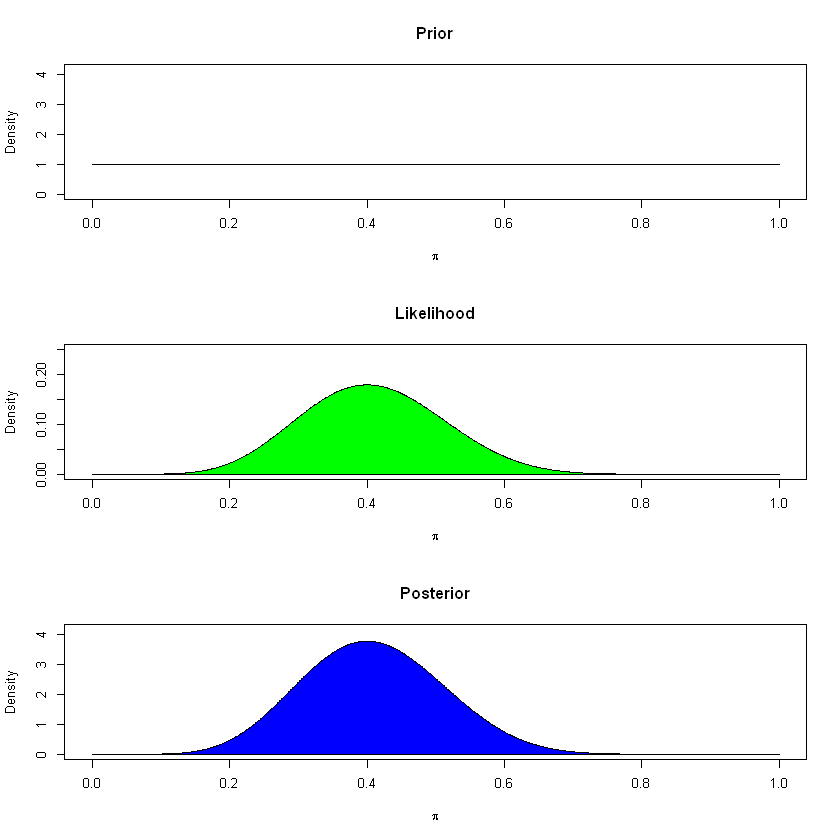

In [3]:
library(Bolstad)
results <- binobp(8, 20, 1, 1, plot = TRUE)
par(mfrow = c(3, 1))
y.lims <- c(0, 1.1*max(results$posterior, results$prior))
plot(results$pi, results$prior, ylim=y.lims, type="l",xlab=expression(pi), ylab="Density", main="Prior")
polygon(results$pi, results$prior, col="red")
plot(results$pi, results$likelihood, ylim=c(0,0.25),type="l",xlab=expression(pi), ylab="Density", main="Likelihood")
polygon(results$pi, results$likelihood, col="green")
plot(results$pi, results$posterior, ylim=y.lims, type="l",xlab=expression(pi), ylab="Density", main="Posterior")
polygon(results$pi, results$posterior, col="blue")

In [4]:
dbda_programs = "../DBDA2Eprograms/"
src = function(name) {
    source(paste0(dbda_programs, name, ".R"))
}

In [10]:
src("DBDA2E-utilities")
src("BernBeta")


*********************************************************************
Kruschke, J. K. (2015). Doing Bayesian Data Analysis, Second Edition:
A Tutorial with R, JAGS, and Stan. Academic Press / Elsevier.
*********************************************************************



In [11]:
t = 0.5 # Specify the prior mode.
n = 25 # Specify the effective prior sample size.
a = t*(n-2) + 1 # Convert to beta shape parameter a.
b = (1-t)*(n-2) + 1 # Convert to beta shape parameter b.
Prior = c(a,b) # Specify Prior as vector with the two shape parameters.
# Specify the data:
N = 20 # The total number of flips.
z = 4 # The number of heads.

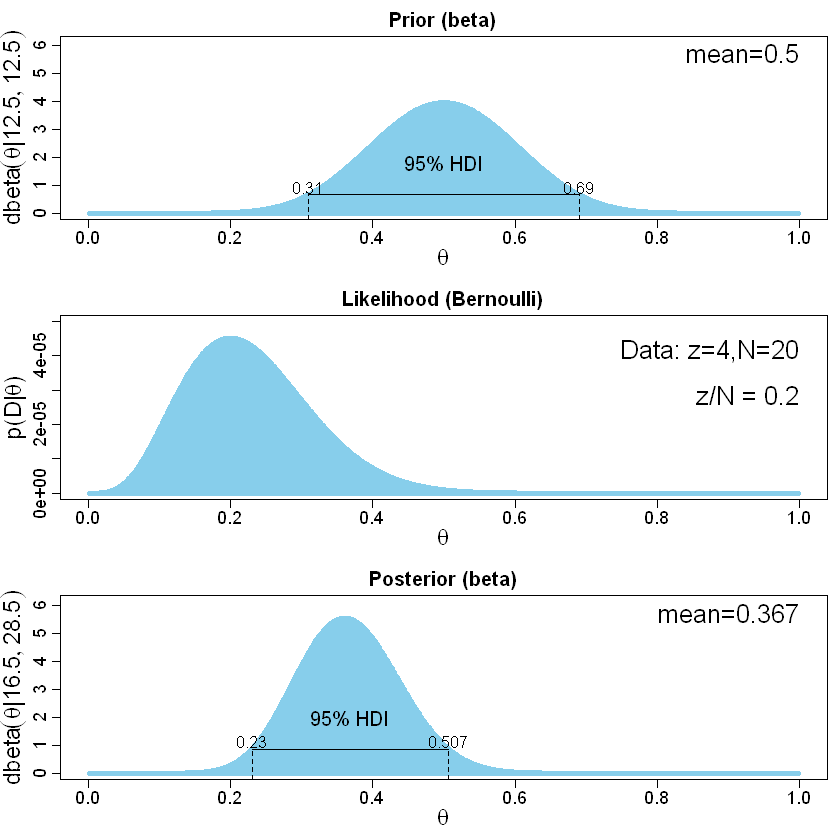

In [13]:
Data = c(rep(0,N-z),rep(1,z)) # Convert N and z into vector of 0’s and 1’s.
posterior = BernBeta( priorBetaAB=Prior, Data=Data , plotType="Bars" ,showCentTend="Mean" , showHDI=TRUE , showpD=FALSE )